# Logical CNOT — Lattice Surgery (Rotated Surface Code)

Lattice-surgery CNOT on the **rotated** surface code, using three patches: Control (C), Target (T), Ancilla (A).

Layout (post-fix rotated convention — verified below with Stim `peek_observable_expectation`):
```
  A — T   (XX merge: side-by-side, offset in x)
  |       (ZZ merge: vertical stack, offset in y)
  C
```
For the rotated code **X̄ runs vertical and Z̄ runs horizontal**, so measuring Z̄Z̄ needs a **vertical stack** and X̄X̄ a **side-by-side** placement. This is the transpose of the naive "merge along same-type edges" intuition, and is exactly the mapping that was fixed in `RotatedTwoPatchCoupler` (`'ZZ'` → grow `distance_x`, `'XX'` → grow `distance_z`).

Two protocol variants (set `PROTOCOL` in the config cell):

| `PROTOCOL` | Ancilla init | Step 1 | Step 2 | Ancilla meas |
|---|---|---|---|---|
| `"ZZ_XX"` | \|+⟩ | ZZ merge (C–A) | XX merge (T–A) | Z |
| `"XX_ZZ"` | \|0⟩ | XX merge (T–A) | ZZ merge (C–A) | X |

The required LS-CNOT sequence — **`ZZ(c,a)` → `XX(a,t)` → final `Z_A` readout** — is the `"ZZ_XX"` variant (the default below).

Five sub-experiments probe all logical input/output basis combinations:

| Sub-experiment | Init C | Init T | Meas C | Meas T |
|---|---|---|---|---|
| ZZ_ZZ | Z | Z | Z | Z |
| ZX_ZX | Z | X | Z | X |
| XZ_XX | X | Z | X | X |
| XZ_ZZ | X | Z | Z | Z |
| XX_XX | X | X | X | X |

Comprehensive protocol LER: `1/4·(ZZ_ZZ + ZX_ZX + 1/2·(XZ_XX + XZ_ZZ) + XX_XX)`.

Code: **Rotated** Surface Code, d=3, p=1e-3. Uses the fixed `RotatedTwoPatchCoupler` with `rotate_patches=False` (the rotated patches are already aligned, so the unrotated rotate/transpose alignment must be disabled).

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import stim

from lightstim.protocols.cnot_ls import CNOTLSExperiment
from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode,
    RotatedSurfaceCodeExtractionBlock,
    RotatedTwoPatchCoupler,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2   # rounds=2 keeps the detector-slice picture simple; the LER cell uses rounds=d (paper convention)
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

# Protocol variant — controls the ancilla init, which fixes the merge order:
#   "ZZ_XX" — ancilla |+>, ZZ merge (C–A) first, then XX merge (T–A), measure A in Z  <-- required CNOT sequence
#   "XX_ZZ" — ancilla |0>, XX merge (T–A) first, then ZZ merge (C–A), measure A in X
PROTOCOL = "ZZ_XX"

# Rotated convention (fixed & Stim-verified): ZZ = vertical stack (offset in y), XX = side-by-side (offset in x).
# Offset magnitude is 2d+2 for the rotated code (vs 2d for the unrotated one).
CNOT_SUB_EXPERIMENTS = [
    # (label,  init_C, init_T, meas_C, meas_T)
    ("ZZ_ZZ", "Z", "Z", "Z", "Z"),
    ("ZX_ZX", "Z", "X", "Z", "X"),
    ("XZ_XX", "X", "Z", "X", "X"),
    ("XZ_ZZ", "X", "Z", "Z", "Z"),
    ("XX_XX", "X", "X", "X", "X"),
]


def build_cnot(d, ic, it, mc, mt, *, protocol=PROTOCOL, rounds=rounds, noise=noise_params):
    "Build one rotated LS-CNOT sub-experiment. Returns (circuit, experiment)."
    ancilla_init = "X" if protocol == "ZZ_XX" else "Z"
    ancilla_meas = "Z" if protocol == "ZZ_XX" else "X"   # |+> -> measure Z, |0> -> measure X
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTLSExperiment(
            patch_configs={"c": {"distance": d}, "t": {"distance": d}, "a": {"distance": d}},
            offset_ca=(0, 2 * d + 2),   # Control below Ancilla  -> ZZ(C,A) vertical stack
            offset_ta=(2 * d + 2, 0),   # Target beside Ancilla  -> XX(A,T) side-by-side
            initial_state_dict={"a": ancilla_init, "c": ic, "t": it},
            measure_state_dict={"a": ancilla_meas, "c": mc, "t": mt},
            code_patch_class=RotatedSurfaceCode,
            coupler_class=RotatedTwoPatchCoupler,
            extraction_block_class=RotatedSurfaceCodeExtractionBlock,
            rotate_patches=False,                          # rotated code already aligned (X̄ vertical / Z̄ horizontal)
            rounds=rounds,
            noise_params=noise,
        )
        circ = exp.build()
    return circ, exp

## Build Circuits

Build all 5 sub-experiments and report size + the **final observable count** (`nobs`).

In [3]:
circuits = {}
print(f"PROTOCOL = {PROTOCOL}    (d={d}, rounds={rounds}, p={p})\n")
print(f"{'sub':8} {'qubits':>7} {'detectors':>10} {'observables':>12}")
print("-" * 42)
for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
    circ, _ = build_cnot(d, ic, it, mc, mt)
    circuits[sub] = circ
    print(f"{sub:8} {circ.num_qubits:7d} {circ.num_detectors:10d} {circ.num_observables:12d}")

PROTOCOL = ZZ_XX    (d=3, rounds=2, p=0.001)

sub       qubits  detectors  observables
------------------------------------------
ZZ_ZZ         65        152            2
ZX_ZX         65        152            2
XZ_XX         65        152            1
XZ_ZZ         65        152            1
XX_XX         65        152            2


## Detector Slice (ZZ_ZZ sub-experiment)

The two seams (the vertical C–A ZZ merge and the horizontal A–T XX merge) are visible in the noiseless detector slice.

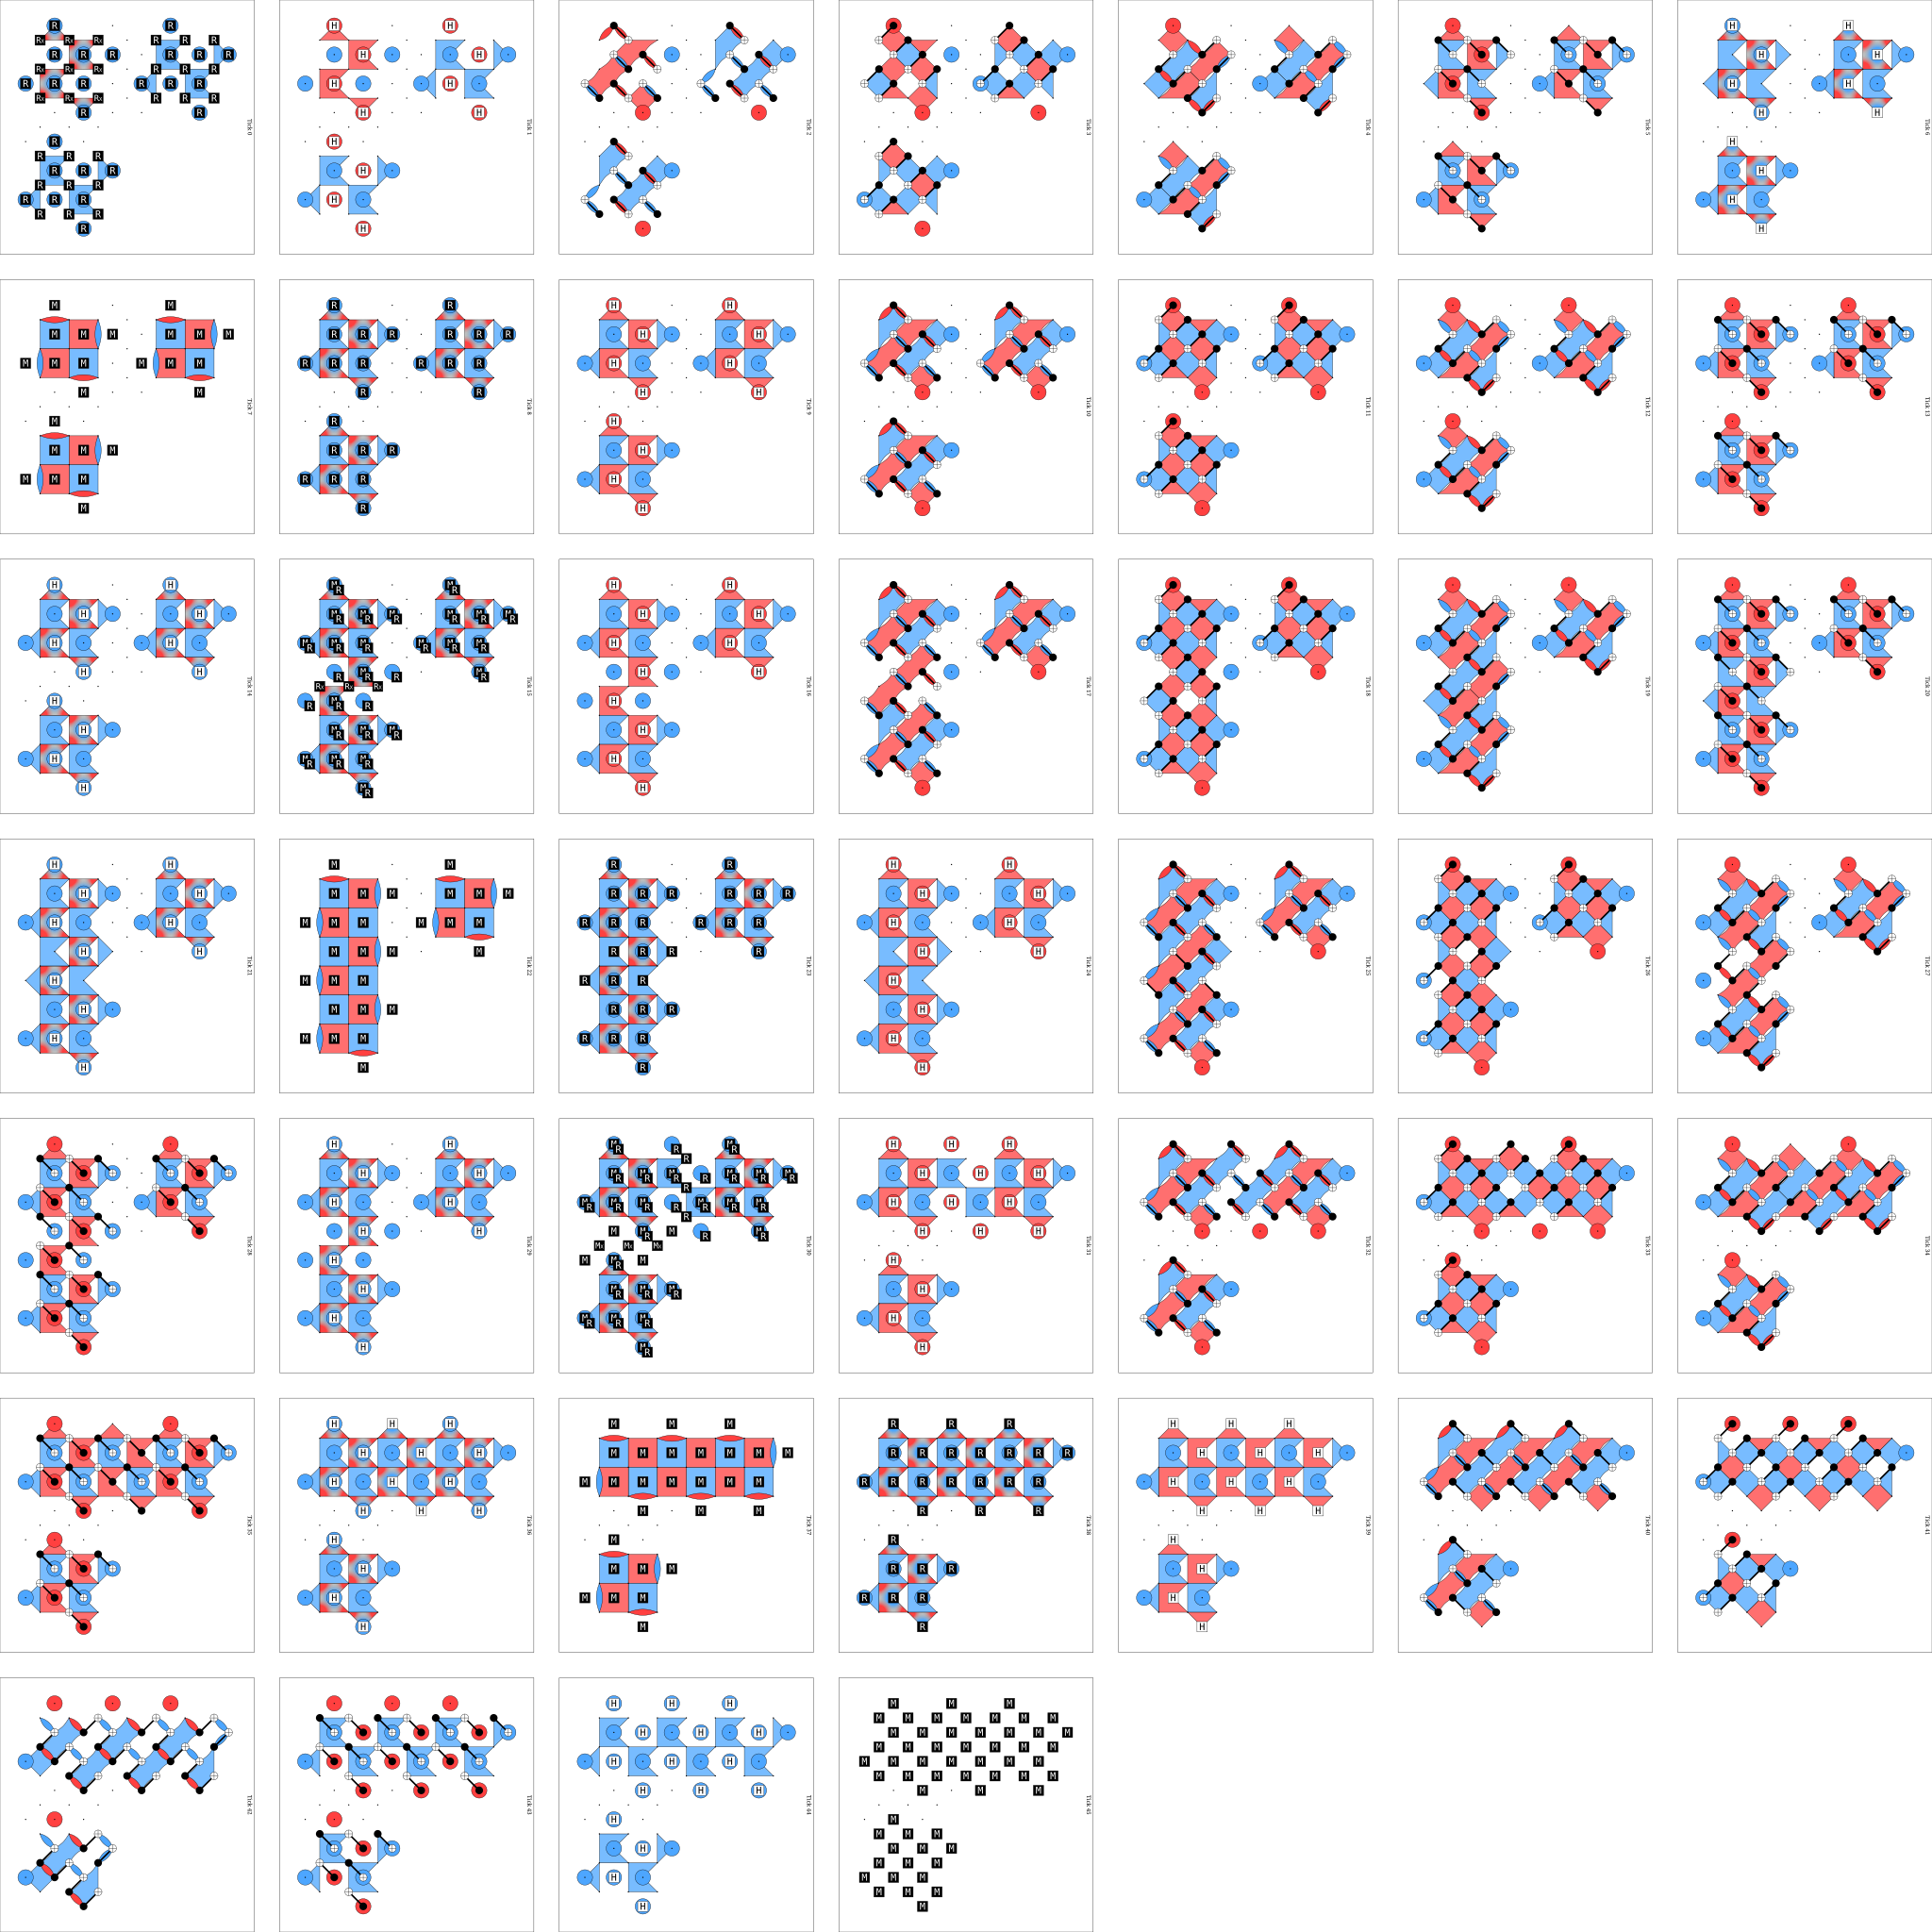

In [4]:
circuits["ZZ_ZZ"].without_noise().diagram("detslice-with-ops-svg")

## Verification 1 — which joint operator does each merge actually measure?

We do **not** trust the high-level `"ZZ"`/`"XX"` labels. Instead we build a noiseless circuit whose init bases keep both joint operators *undetermined until their own merge*, step through it with a `stim.TableauSimulator`, and record the circuit fraction at which each joint operator first goes **undetermined → determined** (`peek_observable_expectation` → ±1). The merge that *measures* a joint operator is the one at which it becomes determined. The couplers are identical across all 5 sub-experiments, so this fixes the merge structure for the whole protocol.

In [5]:
def _logical_rep(system, owner, typ):
    "Return the data-qubit indices of patch owner's logical typ ('X'/'Z') representative."
    for op in system.logical_ops:
        if {system.index_to_owner_map[q] for q in op["data_indices"]} == {owner} and op.get("type") == typ:
            return list(op["data_indices"])
    raise KeyError((owner, typ))


def _pauli(n, idxs, pauli):
    s = ["_"] * n
    for i in idxs:
        s[i] = pauli
    return stim.PauliString("".join(s))


def _first_determined_frac(circ, obs):
    "Circuit fraction at which obs first transitions undetermined -> determined (else None)."
    sim = stim.TableauSimulator()
    flat = circ.flattened()
    N = len(flat)
    prev = None
    for i, inst in enumerate(flat):
        sim.do(inst)
        det = abs(round(sim.peek_observable_expectation(obs))) == 1
        if prev is False and det:
            return i / N
        prev = det
    return None


def _fmt(frac):
    return f"{frac:.2f}" if frac is not None else "never"


def verify_merge_joints(d=3, protocol=PROTOCOL, rounds=2):
    # Choose init bases so Z̄_C·Z̄_A (needs C or A in X) and X̄_A·X̄_T (needs A or T in Z)
    # are BOTH undetermined until their own merge.
    if protocol == "ZZ_XX":      # ancilla is |+> (X) -> supplies X for C–A; put T in Z for A–T
        ic, it = "Z", "Z"
    else:                         # ancilla is |0> (Z) -> supplies Z for A–T; put C in X for C–A
        ic, it = "X", "X"
    circ, exp = build_cnot(d, ic, it, ic, it, protocol=protocol, rounds=rounds, noise=None)
    s, n = exp.system, circ.num_qubits

    zz_ca = _pauli(n, _logical_rep(s, "control", "Z") + _logical_rep(s, "ancilla", "Z"), "Z")
    xx_at = _pauli(n, _logical_rep(s, "ancilla", "X") + _logical_rep(s, "target", "X"), "X")
    xx_ca = _pauli(n, _logical_rep(s, "control", "X") + _logical_rep(s, "ancilla", "X"), "X")  # wrong basis for C–A

    f_zz = _first_determined_frac(circ, zz_ca)
    f_xx = _first_determined_frac(circ, xx_at)
    f_wrong = _first_determined_frac(circ, xx_ca)

    print(f"PROTOCOL = {protocol}  (d={d})\n")
    print(f"  ZZ(C,A) merge -> measures  Z̄_C·Z̄_A : first determined at circuit fraction {_fmt(f_zz)}")
    print(f"  XX(A,T) merge -> measures  X̄_A·X̄_T : first determined at circuit fraction {_fmt(f_xx)}")

    zz_first = (f_zz is not None and f_xx is not None and f_zz < f_xx)
    expected_zz_first = (protocol == "ZZ_XX")
    order = "ZZ(c,a) then XX(a,t)" if zz_first else "XX(a,t) then ZZ(c,a)"
    expected_order = "ZZ(c,a) then XX(a,t)" if expected_zz_first else "XX(a,t) then ZZ(c,a)"
    print(f"\n  merge order : {order}")
    print(f"  expected    : {expected_order}   (from PROTOCOL)")

    # The C–A merge must fix Z̄ (not X̄): the wrong-basis joint X̄_C·X̄_A must NOT become
    # determined at the C–A merge.
    wrong_clean = (f_wrong is None) or (abs(f_wrong - (f_zz or 0)) > 0.05)
    print(f"  C–A merge fixes Z̄ not X̄ : X̄_C·X̄_A first determined at {_fmt(f_wrong)} "
          f"-> {'OK (≠ ZZ merge point)' if wrong_clean else 'SUSPECT'}")

    ok = (f_zz is not None and f_xx is not None and (zz_first == expected_zz_first) and wrong_clean)
    print(f"\n  => joint-operator verification: {'PASS ✅' if ok else 'FAIL ❌'}")
    return ok


assert verify_merge_joints(d=3, protocol=PROTOCOL), "merge joint-operator verification failed"
print("\n(verifying the other protocol variant for completeness)\n")
assert verify_merge_joints(d=3, protocol="XX_ZZ" if PROTOCOL == "ZZ_XX" else "ZZ_XX")

PROTOCOL = ZZ_XX  (d=3)

  ZZ(C,A) merge -> measures  Z̄_C·Z̄_A : first determined at circuit fraction 0.47
  XX(A,T) merge -> measures  X̄_A·X̄_T : first determined at circuit fraction 0.73

  merge order : ZZ(c,a) then XX(a,t)
  expected    : ZZ(c,a) then XX(a,t)   (from PROTOCOL)
  C–A merge fixes Z̄ not X̄ : X̄_C·X̄_A first determined at never -> OK (≠ ZZ merge point)

  => joint-operator verification: PASS ✅

(verifying the other protocol variant for completeness)

PROTOCOL = XX_ZZ  (d=3)

  ZZ(C,A) merge -> measures  Z̄_C·Z̄_A : first determined at circuit fraction 0.73
  XX(A,T) merge -> measures  X̄_A·X̄_T : first determined at circuit fraction 0.47

  merge order : XX(a,t) then ZZ(c,a)
  expected    : XX(a,t) then ZZ(c,a)   (from PROTOCOL)
  C–A merge fixes Z̄ not X̄ : X̄_C·X̄_A first determined at 0.47 -> OK (≠ ZZ merge point)

  => joint-operator verification: PASS ✅


## Verification 2 — clean build, DEM validity, and observable count vs unrotated

Each sub-experiment must (a) be **noiseless-clean** (no detector/observable fires with noise off), (b) have a **valid decomposed DEM**, and (c) produce the **same number of logical observables** as the unrotated LS-CNOT.

In [6]:
# Reference: the unrotated LS-CNOT observable counts (matched exactly by the rotated build).
UNROTATED_NOBS = {"ZZ_ZZ": 2, "ZX_ZX": 2, "XZ_XX": 1, "XZ_ZZ": 1, "XX_XX": 2}

print(f"{'sub':8} {'clean':>6} {'dem_valid':>10} {'nobs':>5} {'unrot':>6} {'match':>6}")
print("-" * 46)
all_ok = True
for sub, circ in circuits.items():
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=500, separate_observables=True)
    clean = (not det.any()) and (not obs.any())
    try:
        circ.detector_error_model(decompose_errors=True)
        dem_valid = True
    except Exception:
        dem_valid = False
    nobs = circ.num_observables
    ref = UNROTATED_NOBS[sub]
    match = (nobs == ref)
    all_ok &= clean and dem_valid and match
    print(f"{sub:8} {str(clean):>6} {str(dem_valid):>10} {nobs:5d} {ref:6d} {str(match):>6}")

print(f"\nAll 5 sub-experiments clean + DEM-valid + nobs matches unrotated: {all_ok}")
assert all_ok

sub       clean  dem_valid  nobs  unrot  match
----------------------------------------------
ZZ_ZZ      True       True     2      2   True
ZX_ZX      True       True     2      2   True
XZ_XX      True       True     1      1   True
XZ_ZZ      True       True     1      1   True
XX_XX      True       True     2      2   True

All 5 sub-experiments clean + DEM-valid + nobs matches unrotated: True


## Verification 3 — LER distance suppression (d=3 vs d=5)

Quick sanity check at `p=1e-3` with `rounds=d` (paper convention). Error correction works iff the larger code suppresses the logical error rate: **LER(d=5) < LER(d=3)**. We report per-sub-experiment LER and the comprehensive weighted average.

In [7]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=200_000,
    max_errors=60,
    num_workers=8,
    print_progress=False,
)

# weights for the comprehensive protocol LER: 1/4·(ZZ_ZZ + ZX_ZX + 1/2·(XZ_XX + XZ_ZZ) + XX_XX)
WEIGHTS = {"ZZ_ZZ": 1 / 4, "ZX_ZX": 1 / 4, "XZ_XX": 1 / 8, "XZ_ZZ": 1 / 8, "XX_XX": 1 / 4}

ler_by_d = {}
for dd in (3, 5):
    print(f"--- d={dd}, rounds={dd}, p={p} ---")
    per_sub = {}
    for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
        circ, _ = build_cnot(dd, ic, it, mc, mt, rounds=dd,
                             noise=NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p))
        stats = pipeline.run(circ)
        per_sub[sub] = stats.logical_error_rate
        print(f"  {sub:8}: LER={stats.logical_error_rate:.3e}  ({stats.errors} err / {stats.shots:,} shots)")
    comp = sum(WEIGHTS[s] * per_sub[s] for s in per_sub)
    ler_by_d[dd] = comp
    print(f"  comprehensive LER = {comp:.3e}\n")

print(f"LER(d=3) = {ler_by_d[3]:.3e}")
print(f"LER(d=5) = {ler_by_d[5]:.3e}")
suppressed = ler_by_d[5] < ler_by_d[3]
print(f"distance suppression  LER(d=5) < LER(d=3): {suppressed}  "
      f"(factor ≈ {ler_by_d[3] / ler_by_d[5]:.1f}x)")
assert suppressed, "expected distance suppression LER(d=5) < LER(d=3)"
print("\n✅ Rotated LS-CNOT: clean build, DEM-valid, nobs matches unrotated, and LER is distance-suppressed.")

--- d=3, rounds=3, p=0.001 ---


  ZZ_ZZ   : LER=1.524e-02  (1067 err / 70,000 shots)


  ZX_ZX   : LER=9.750e-03  (585 err / 60,000 shots)


  XZ_XX   : LER=1.406e-02  (1125 err / 80,000 shots)


  XZ_ZZ   : LER=1.291e-02  (904 err / 70,000 shots)


...

  ZZ_ZZ   : LER=1.433e-03  (172 err / 120,000 shots)


  ZX_ZX   : LER=1.117e-03  (134 err / 120,000 shots)


  XZ_XX   : LER=1.718e-03  (189 err / 110,000 shots)


  XZ_ZZ   : LER=1.336e-03  (147 err / 110,000 shots)


  XX_XX   : LER=2.280e-03  (228 err / 100,000 shots)
  comprehensive LER = 1.589e-03

LER(d=3) = 1.402e-02
LER(d=5) = 1.589e-03
distance suppression  LER(d=5) < LER(d=3): True  (factor ≈ 8.8x)

✅ Rotated LS-CNOT: clean build, DEM-valid, nobs matches unrotated, and LER is distance-suppressed.
